In [1]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 2.1/100.2 MB 10.7 MB/s eta 0:00:10
   - -------------------------------------- 4.5/100.2 MB 11.7 MB/s eta 0:00:09
   -- ------------------------------------- 6.6/100.2 MB 11.2 MB/s eta 0:00:09
   --- ------------------------------------ 7.9/100.2 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 9.7/100.2 MB 9.6 MB/s eta 0:00:10
   ---- ----------------------------------- 12.1/100.2 MB 9.8 MB/s eta 0:00:10
   ----- ---------------------------------- 14.7/100.2 MB 10.1 MB/s eta 0:00:09
   ------ --------------------------------- 17.0/100.2 MB 10.2 MB/s eta 0:00:09
   ------- -------------------------------- 19.4/100.2 MB 10.5 MB/s eta 0:00:08
   -------- ------------------------------- 21.2/100.2 MB 10.5 MB/s eta 0:00:08
   --------- ------------------------------ 23.9/100.2 MB 10.4 MB/s eta 0:00:08
   ---------- ----------------------------- 26.5/100.2 MB

In [3]:
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [40]:
df = pd.read_csv("data/combined_data.csv")
print(df.columns)
exclude = ["describtion", "price", "id", "booked_days", "booked_winter", "booked_summer", "booked_spring", "booked_fall", "booked_weekdays", "booked_weekenddays", "availability_365"]
all_features = [col for col in df.columns if col not in exclude]



Index(['id', 'price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'minimum_nights', 'maximum_nights', 'instant_bookable',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'reviews_per_month', 'host_is_superhost',
       'host_response_rate', 'host_total_listings_count', 'name',
       'description', 'amenities', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'booked_days', 'booked_weekdays',
       'booked_weekenddays', 'booked_winter', 'booked_spring', 'booked_summer',
       'booked_fall', 'booked_range'],
      dtype='object')


In [41]:
categorical_features = []
text_features = []
numeric_features = []

for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        numeric_features.append(col)
    else:
        # object dtype → könnte Kategorie oder Text sein
        avg_len = df[col].astype(str).str.len().mean()

        if avg_len < 30:
            categorical_features.append(col)
        else:
            text_features.append(col)

In [42]:
for col in text_features:
    df[col] = df[col].fillna("")

df["description"] = df["description"].astype(str)
df["description"] = df["description"].replace("nan", "")
df["description"] = df["description"].fillna("")
df["description"] = df["description"].str.strip()

X_all = df[all_features]
y_all = df["price"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [43]:
X_train = X_train_all[all_features]
X_test = X_test_all[all_features]

In [44]:
for col in text_features:
    df[col] = df[col].fillna("")

df["description"] = df["description"].astype(str)
df["description"] = df["description"].replace("nan", "")
df["description"] = df["description"].fillna("")
df["description"] = df["description"].str.strip()

In [45]:
col = X_train.columns[21]
print("Spalte:", col)
print("Wert in X_train.iloc[30]:", X_train.iloc[30][col])
print("Typ:", type(X_train.iloc[30][col]))


Spalte: description
Wert in X_train.iloc[30]: 
Typ: <class 'str'>


In [52]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

model.fit(
    X_train,
    y_train_all,
    cat_features=categorical_features,
    text_features=text_features
)


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=False)

In [53]:
y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test_all, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 39.156968526996515
RMSE: 72.0371376539079


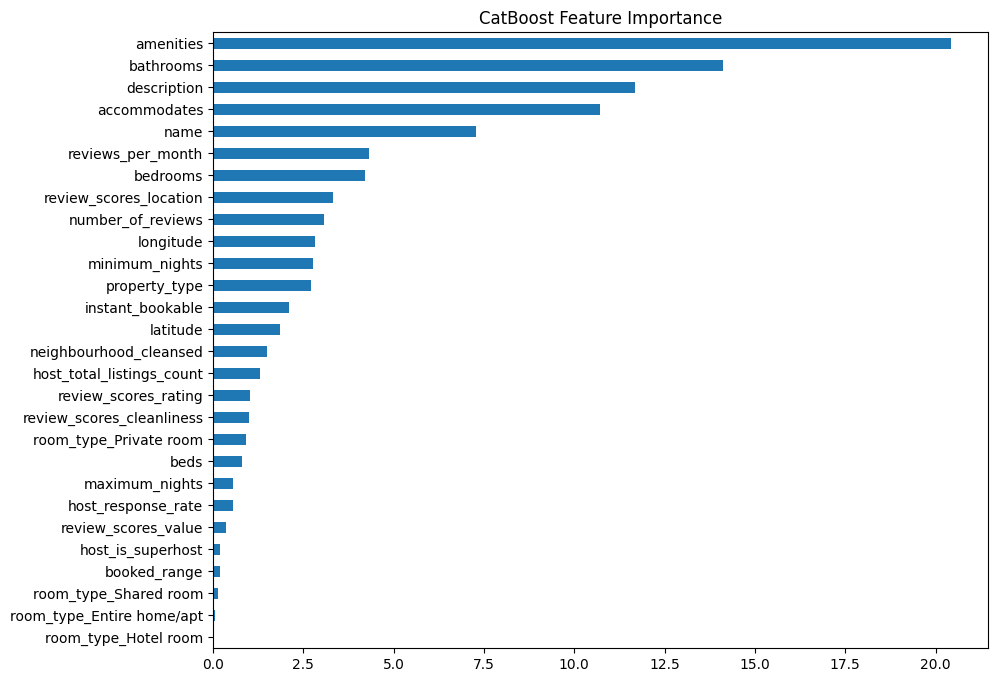

In [54]:


importances = model.get_feature_importance()
feat_names = X_train.columns

pd.Series(importances, index=feat_names).sort_values().plot(kind="barh", figsize=(10,8))
plt.title("CatBoost Feature Importance")
plt.show()

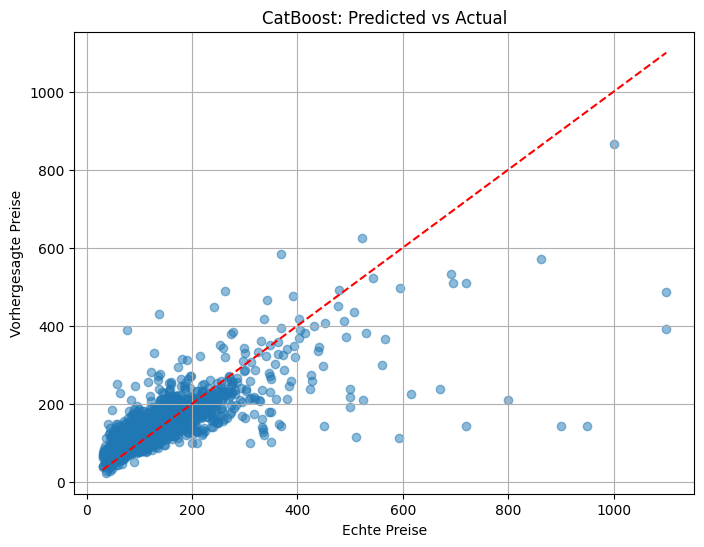

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_all, y_pred, alpha=0.5)
plt.plot([y_test_all.min(), y_test_all.max()],
         [y_test_all.min(), y_test_all.max()],
         "r--")
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("CatBoost: Predicted vs Actual")
plt.grid(True)
plt.show()

In [59]:
# erstmal nur mit wichtigsten features weiter machen
important_feats = pd.Series(importances, index=feat_names).sort_values(ascending=False)
top_feats = important_feats.head(10).index.tolist()

X_train_small = X_train[top_feats]
X_test_small = X_test[top_feats]

0:	learn: 112.3026040	test: 105.1362079	best: 105.1362079 (0)	total: 702ms	remaining: 5m 50s
100:	learn: 78.7339744	test: 79.4789898	best: 79.4789898 (100)	total: 1m 4s	remaining: 4m 13s
200:	learn: 70.2680943	test: 76.1543024	best: 76.1543024 (200)	total: 2m 4s	remaining: 3m 4s
300:	learn: 62.5403905	test: 73.7334430	best: 73.7334430 (300)	total: 3m 6s	remaining: 2m 3s
400:	learn: 56.6285378	test: 72.5792359	best: 72.5792359 (400)	total: 4m 9s	remaining: 1m 1s
499:	learn: 52.2805077	test: 72.0371377	best: 72.0240265 (496)	total: 5m 12s	remaining: 0us

bestTest = 72.02402645
bestIteration = 496

Shrink model to first 497 iterations.


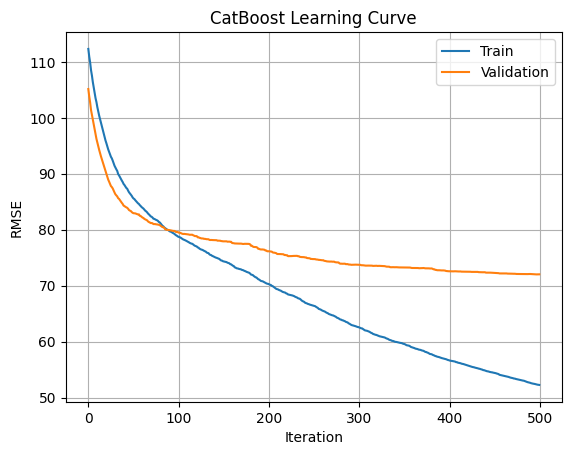

In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

model.fit(
    X_train,
    y_train_all,
    cat_features=categorical_features,
    text_features=text_features,
    eval_set=(X_test, y_test_all)
)

learn_curve = model.get_evals_result()

plt.plot(learn_curve['learn']['RMSE'], label="Train")
plt.plot(learn_curve['validation']['RMSE'], label="Validation")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curve")
plt.grid(True)
plt.legend()
plt.show()

0:	learn: 113.4876916	test: 106.1757064	best: 106.1757064 (0)	total: 748ms	remaining: 6m 13s
100:	learn: 95.8262214	test: 90.0865799	best: 90.0865799 (100)	total: 1m 6s	remaining: 4m 23s
200:	learn: 87.9461653	test: 84.2012100	best: 84.2012100 (200)	total: 2m 7s	remaining: 3m 9s
300:	learn: 83.7822095	test: 81.8055292	best: 81.8029517 (299)	total: 3m 7s	remaining: 2m 3s
400:	learn: 80.8799824	test: 80.5252086	best: 80.5252086 (400)	total: 4m 8s	remaining: 1m 1s
499:	learn: 78.8403458	test: 79.7271174	best: 79.7271174 (499)	total: 5m 12s	remaining: 0us

bestTest = 79.72711737
bestIteration = 499



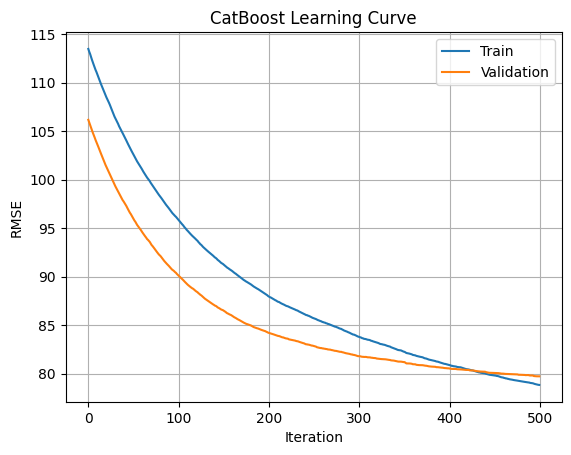

In [62]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.01,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

model.fit(
    X_train,
    y_train_all,
    cat_features=categorical_features,
    text_features=text_features,
    eval_set=(X_test, y_test_all)
)

learn_curve = model.get_evals_result()

plt.plot(learn_curve['learn']['RMSE'], label="Train")
plt.plot(learn_curve['validation']['RMSE'], label="Validation")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curve")
plt.grid(True)
plt.legend()
plt.show()

0:	learn: 108.1579294	test: 101.5748799	best: 101.5748799 (0)	total: 509ms	remaining: 4m 13s
100:	learn: 57.4307393	test: 74.8249557	best: 74.8249557 (100)	total: 1m 5s	remaining: 4m 18s
200:	learn: 41.7152638	test: 72.2965345	best: 72.2587334 (199)	total: 2m 11s	remaining: 3m 15s
300:	learn: 32.6357895	test: 71.8583432	best: 71.7820072 (296)	total: 3m 14s	remaining: 2m 8s
400:	learn: 26.2355787	test: 71.4802151	best: 71.3041473 (366)	total: 4m 18s	remaining: 1m 3s
499:	learn: 21.3891670	test: 70.9180044	best: 70.9180044 (499)	total: 5m 19s	remaining: 0us

bestTest = 70.91800443
bestIteration = 499



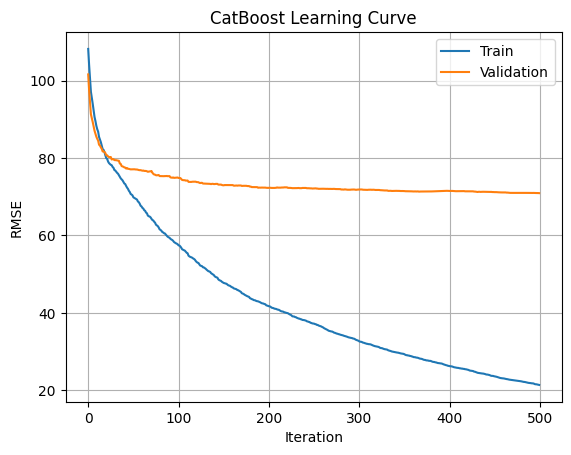

In [63]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.2,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

model.fit(
    X_train,
    y_train_all,
    cat_features=categorical_features,
    text_features=text_features,
    eval_set=(X_test, y_test_all)
)

learn_curve = model.get_evals_result()

plt.plot(learn_curve['learn']['RMSE'], label="Train")
plt.plot(learn_curve['validation']['RMSE'], label="Validation")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curve")
plt.grid(True)
plt.legend()
plt.show()